In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV file
sheet_id = "1tEf8J1kbGZEFTOkoYqIjsdE3PkqBA9bX4MdNfMoLhjQ"
tab_gid = "1121709273"
full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"
df = pd.read_csv(full_url, skiprows=1).iloc[:28,:]
df

,Model,Compression,Size (MB),ROC_AUC,PR_AUC,bootst_roc_auc_mean,bootst_roc_auc_std,ROC_AUC.1,PR_AUC.1,bootst_roc_auc_mean.1,bootst_roc_auc_std.1,ROC_AUC.2,PR_AUC.2,bootst_roc_auc_mean.2,bootst_roc_auc_std.2,ROC_AUC.3,PR_AUC.3,bootst_roc_auc_mean.3,bootst_roc_auc_std.3
0,pythia-70M,Original,281.731840,0.645490,0.60866,0.35463,0.01225,0.64906,0.61320,0.35195,0.01238,0.66505,0.62855,0.33487,0.01220,0.61867,0.56285,0.38099,0.01249
1,pythia-70M,8-bit,122.126910,0.645250,0.60859,0.35487,0.01226,0.64803,0.61204,0.35299,0.01240,0.66492,0.62869,0.33499,0.01221,0.61855,0.56315,0.38113,0.01247
2,pythia-70M,4-bit,113.771070,0.633570,0.60442,0.36652,0.01244,0.63208,0.60402,0.36901,0.01260,0.65657,0.62541,0.34318,0.01225,0.58659,0.54286,0.41308,0.01261
3,pythia-70M,8-bit dyn.,147.859950,0.567270,0.56573,0.43251,0.01297,0.51398,0.50465,0.48671,0.01296,0.61614,0.60081,0.38323,0.01253,0.42853,0.43641,0.57134,0.01325
4,gpt-neo-125M,Original,500.000000,0.641278,0.60800,0.35883,0.01217,0.64276,0.60956,0.35829,0.01235,0.65977,0.62514,0.34037,0.01233,0.58146,0.55414,0.41785,0.01250
5,gpt-neo-125M,8-bit,165.880000,0.637613,0.60689,0.36250,0.01222,0.63975,0.60729,0.36128,0.01236,0.65722,0.62423,0.34288,0.01232,0.57208,0.54785,0.42725,0.01255
6,gpt-neo-125M,4-bit,128.000000,0.595357,0.58776,0.40460,0.01280,0.60668,0.59279,0.39433,0.01261,0.62578,0.60896,0.37412,0.01254,0.47033,0.48068,0.52910,0.01306
7,gpt-neo-125M,8-bit dyn.,284.690000,0.567632,0.57591,0.43219,0.01305,0.58455,0.58026,0.41619,0.01276,0.61017,0.59721,0.38952,0.01262,0.45473,0.47202,0.54454,0.01287
8,pythia-160M,Original,649.341190,0.657010,0.61645,0.34317,0.01195,0.65590,0.61574,0.34520,0.01235,0.67443,0.63549,0.32555,0.01212,0.63949,0.58167,0.36020,0.01221
9,pythia-160M,8-bit,240.116640,0.656575,0.61566,0.34360,0.01195,0.65523,0.61455,0.34589,0.01237,0.67410,0.63498,0.32587,0.01214,0.63815,0.58095,0.36153,0.01223


In [31]:
def genGraph(df, miaName):
    scoreName = df.columns[3].split(".")[0]
    # Extract unique model names
    models = df["Model"].unique()
    compressions = df["Compression"].unique()

    # Define bar width and colors
    bar_width = 0.2
    colors = ["blue", "green", "orange", "red"]

    x = np.arange(len(models))  # X-axis positions

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot bar chart for model sizes
    for i, comp in enumerate(compressions):
        subset = df[df["Compression"] == comp]
        ax1.bar(x + i * bar_width, subset["Size (MB)"], width=bar_width, label=f"{comp} Model Size (MB)", alpha=0.7, color=colors[i])

    ax1.set_ylabel("Model Size (MB)")
    ax1.set_xticks(x + bar_width * 1.5)
    ax1.set_xticklabels(models, rotation=15)
    ax1.legend(loc="upper left")

    # Second y-axis for performance scores
    ax2 = ax1.twinx()

    # Plot line chart for performance
    for i, comp in enumerate(compressions):
        subset = df[df["Compression"] == comp]
        ax2.plot(x + i * bar_width, subset.iloc[:,3], marker="o", linestyle="-", label=f"{comp} {scoreName} ({miaName}) (%)", color=colors[i])

    ax2.set_ylabel(f"{scoreName} ({miaName}) (%)")
    ax2.legend(loc="center left", bbox_to_anchor=(0, 0.3))
    # ax2.legend(loc="upper right")

    plt.title(f"Comparison of Model Sizes and MIA ({miaName}) Across Compression Levels")
    plt.savefig(f"./output/{scoreName}({miaName}).png", dpi=300, bbox_inches="tight")
    plt.show()

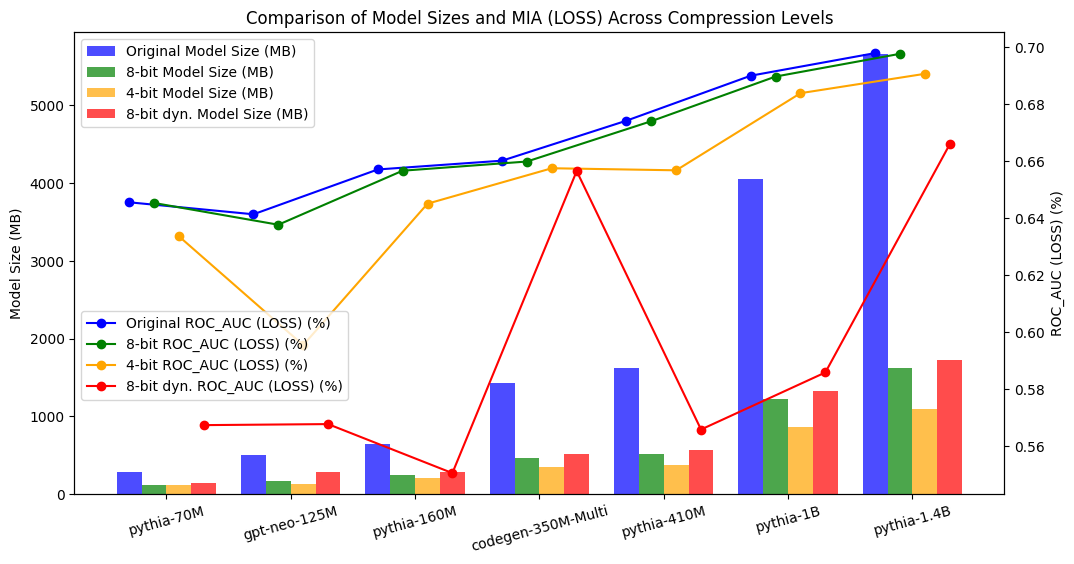

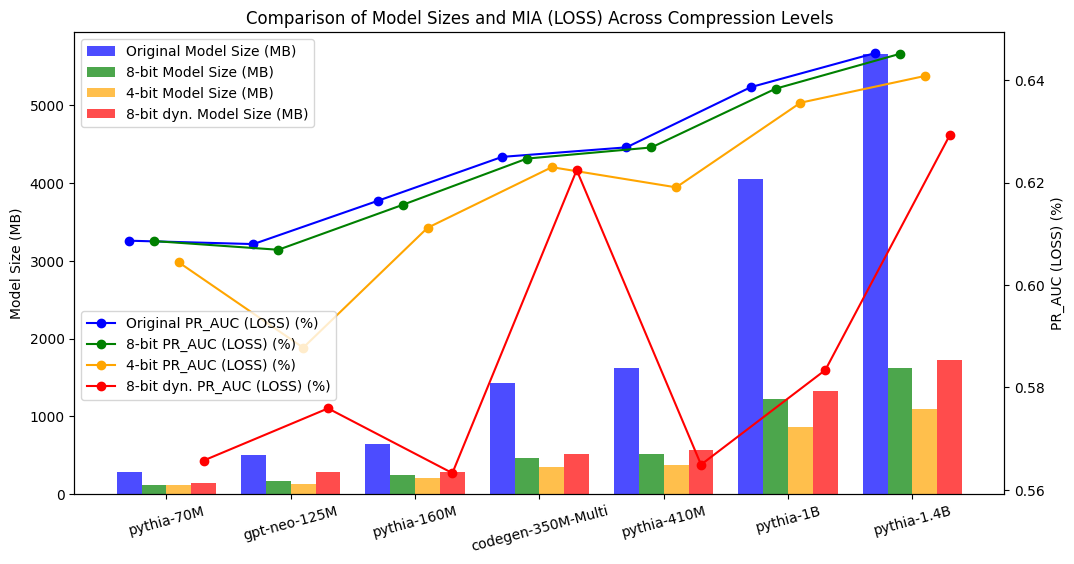

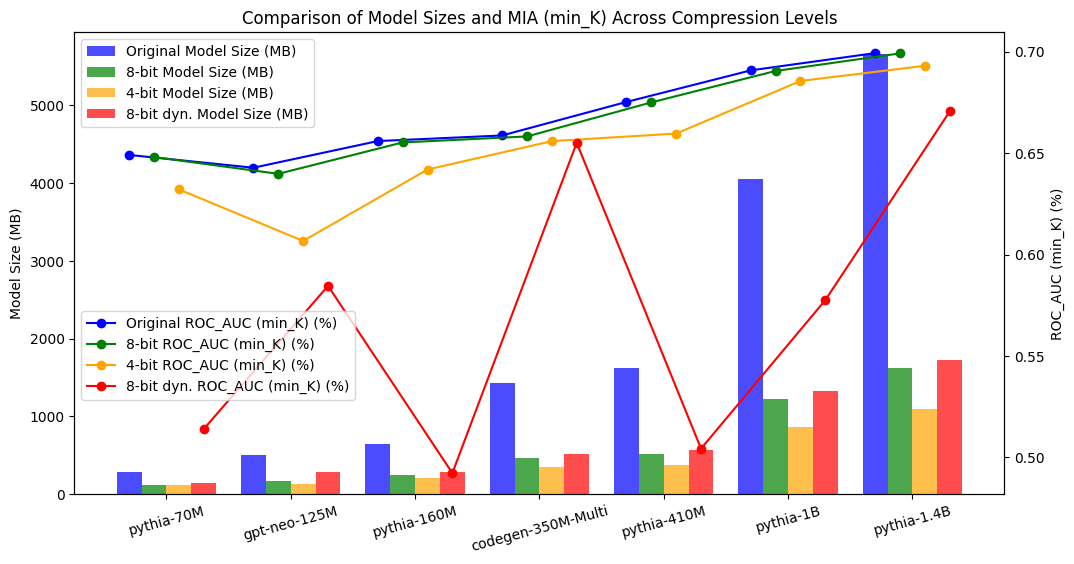

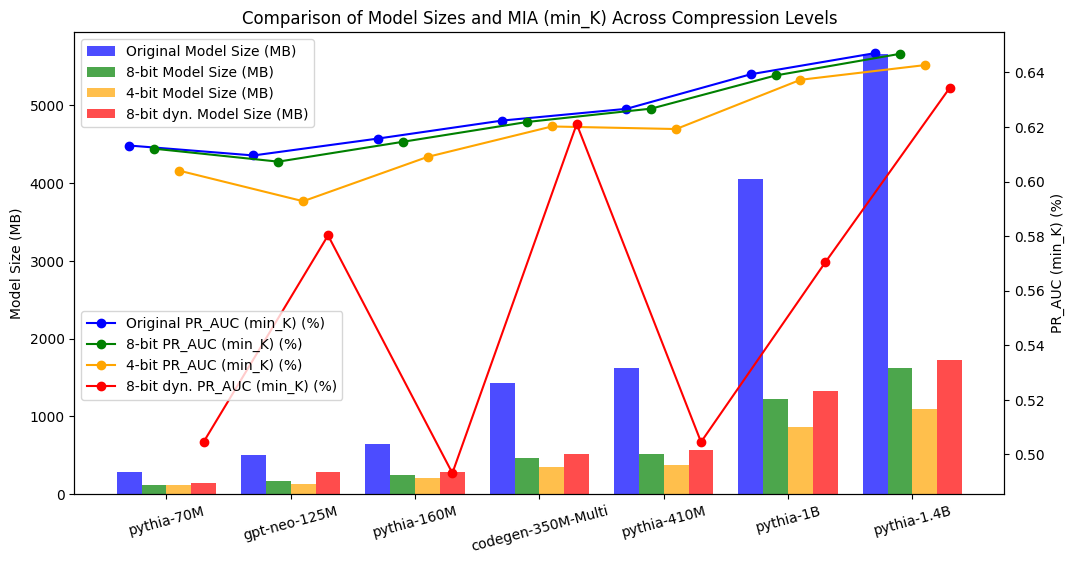

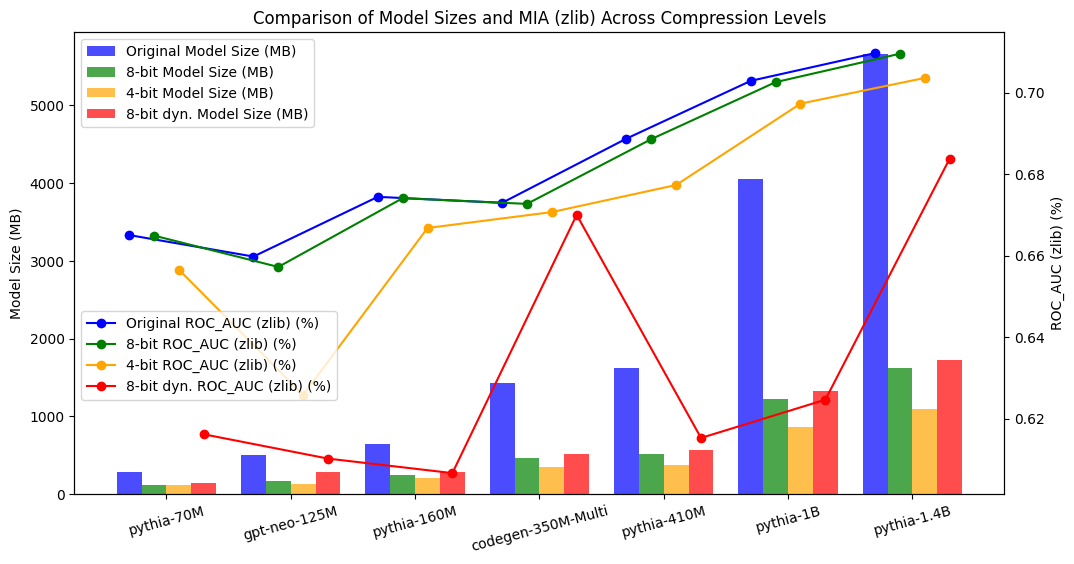

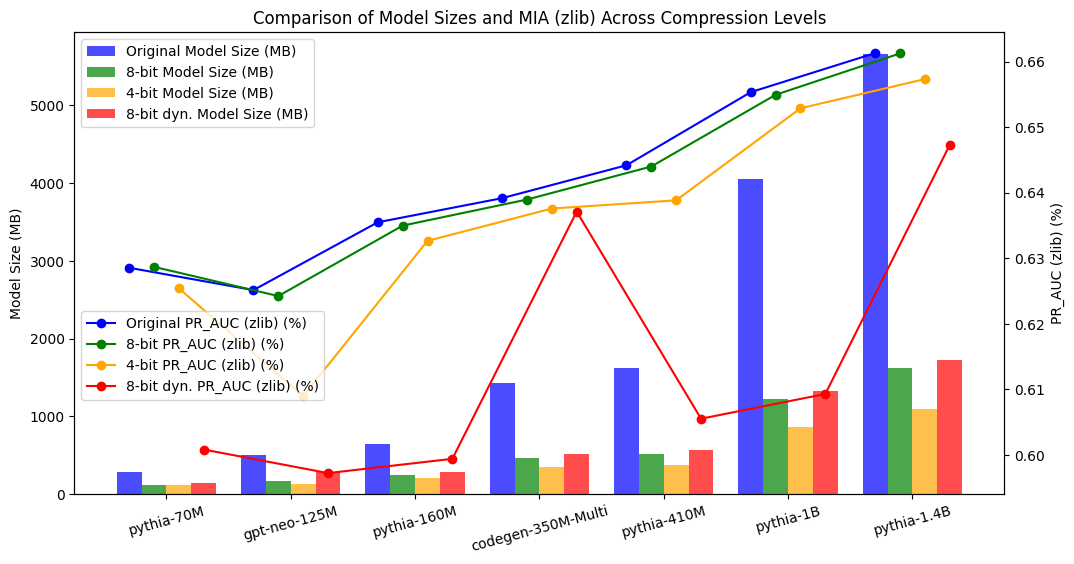

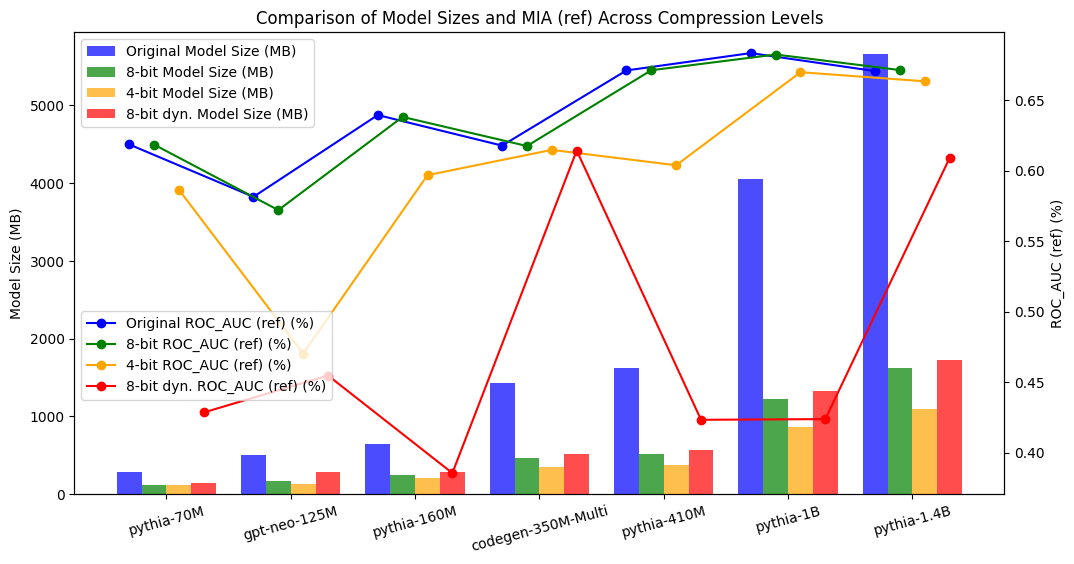

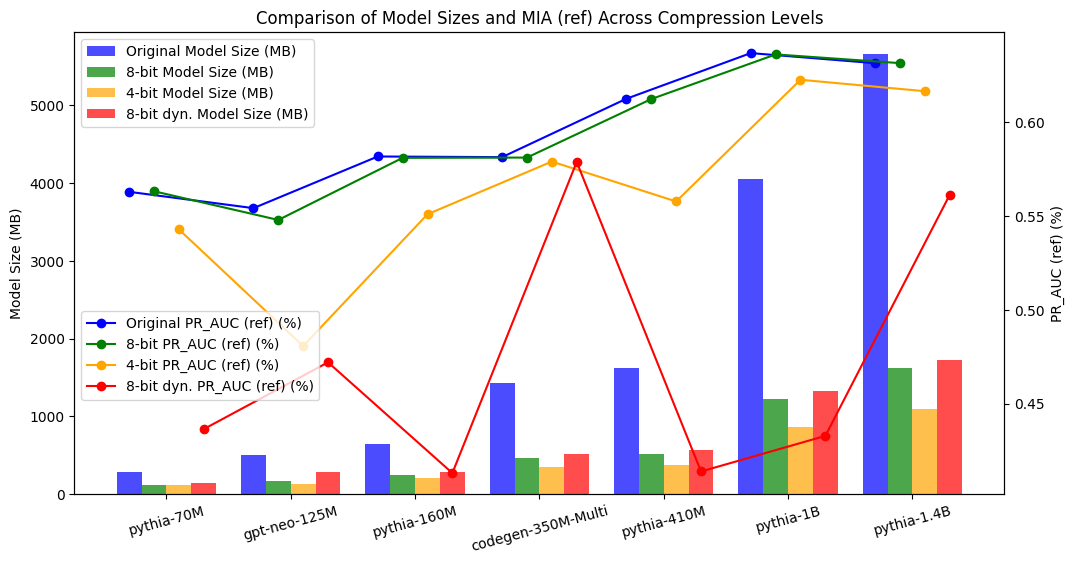

In [32]:
genGraph(df.iloc[:, [0,1,2,3]], miaName="LOSS")
genGraph(df.iloc[:, [0,1,2,4]], miaName="LOSS")
genGraph(df.iloc[:, [0,1,2,7]], miaName="min_K")
genGraph(df.iloc[:, [0,1,2,8]], miaName="min_K")
genGraph(df.iloc[:, [0,1,2,11]], miaName="zlib")
genGraph(df.iloc[:, [0,1,2,12]], miaName="zlib")
genGraph(df.iloc[:, [0,1,2,15]], miaName="ref")
genGraph(df.iloc[:, [0,1,2,16]], miaName="ref")